# Exploring the tumor

This notebook digs into the **biology** stage: spatial structure, the CINner-style selection
model, clonal dynamics, and how treatment acts on cells. We rebuild the same small tumor the
other notebooks use (`example_config.yaml`, seed 2), keeping the live `Tumor` object so we can
colour the spatial grid by any per-cell quantity.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iscc
from iscc.tumor.models import GenotypeTumor
from iscc.constants import normal_names

CONFIG = os.path.join(os.getcwd(), "example_config.yaml")
# The same cm-scale DCIS -> IDC tissue as the other notebooks (~8.5 mm, ~10^6 cells). Growing to the
# DCIS->IDC state takes ~3 min (tau-leaping + passenger coarsening).
tumor = GenotypeTumor(config=CONFIG, seed=2)
tumor.grow(n_steps=150, seed=2)
print("cancer:", tumor.get_cancer_size(), "| total:", tumor.get_tumor_size(),
      "| genome:", tumor.n_genes, "genes")

cancer: 323342 | total: 588938 | genome: 600 genes


## Spatial structure

`plot_tissue` draws the **deme grid straight from the per-deme counts**, so the spatial overview stays
complete at cm-scale (`plot_grid`, which reads the memory-safe `cell_data` subsample, would go holey).
The `"state"` view is categorical — stroma / duct(normal) / **DCIS** (cancer inside a duct) / **IDC**
(cancer invaded into the stroma) — and `"cancer_frac"` is the per-deme cancer fraction. You can see the
single clone's DCIS ducts and the focal invasive masses that broke out of them.

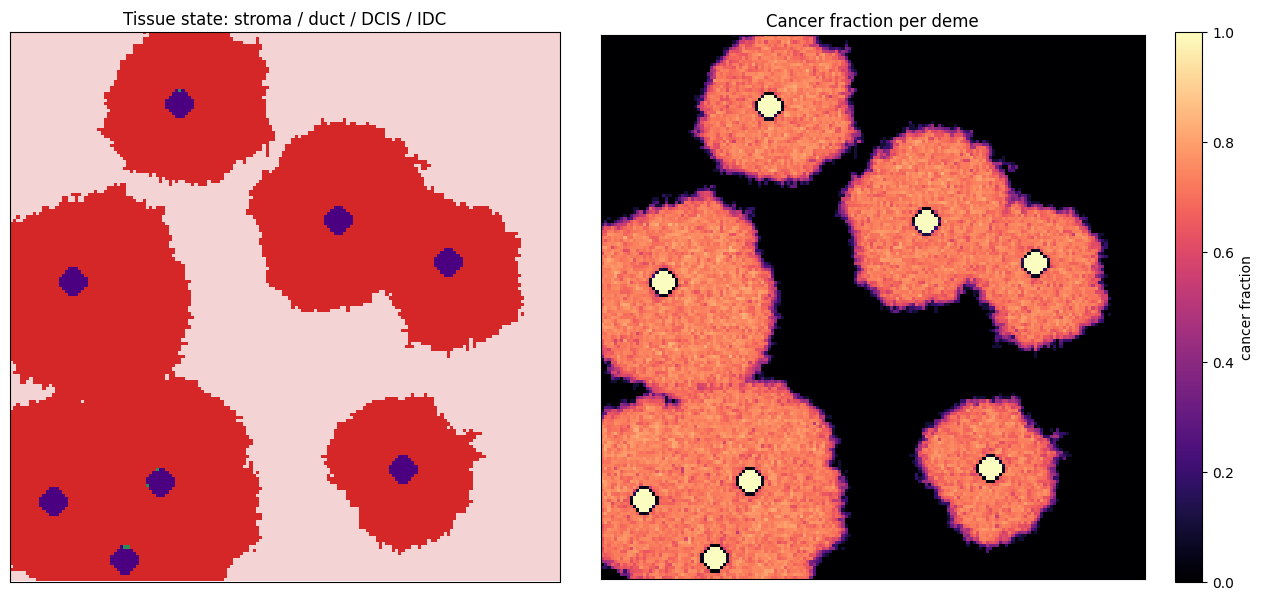

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
tumor.plot_tissue(ax=axes[0], color="state")
axes[0].set_title("Tissue state: stroma / duct / DCIS / IDC")
tumor.plot_tissue(ax=axes[1], color="cancer_frac")
axes[1].set_title("Cancer fraction per deme")
plt.tight_layout()

## Clonal dynamics

The Muller plot shows how cancer clones rise and fall over the simulation.

Text(0.5, 1.0, 'Clonal dynamics (by driver clone) — a single founder + its subclones')

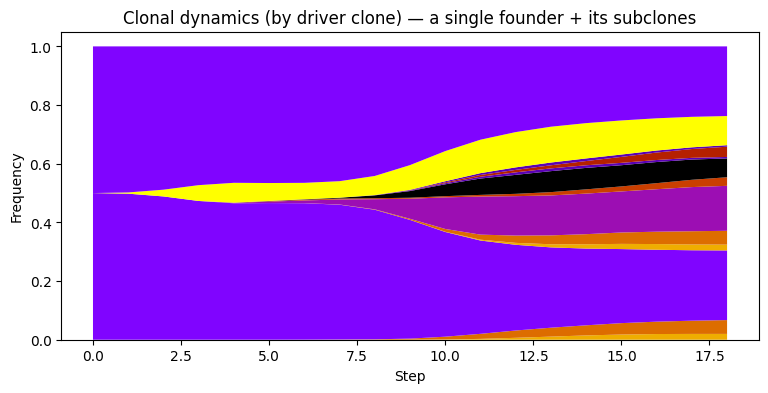

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
tumor.plot_muller(ax=ax, by_drivers=True, min_freq=0.02)
ax.set_title("Clonal dynamics (by driver clone) — a single founder + its subclones")

## The CINner-style selection model

Fitness is copy-number aware: oncogene copies/mutations raise the division rate,
tumour-suppressor copies/mutations lower it. We can see this in the per-cell ground truth —
cells carrying more mutated oncogenes tend to divide faster.

Text(0.5, 1.0, 'Selection: driver load vs fitness')

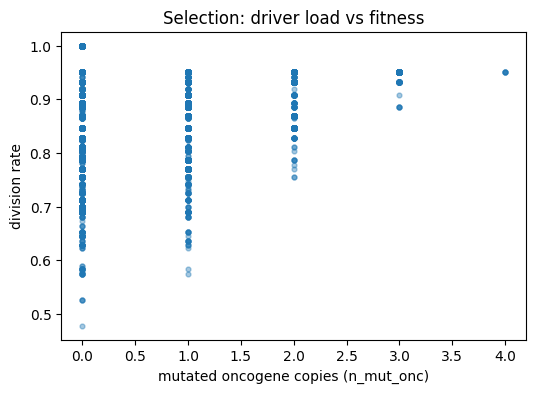

In [4]:
evo = tumor.cell_data["cell_evo"].copy()
evo = evo[evo["division_rate"] > 0]  # cancer cells (normal cells have division_rate 0)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(evo["n_mut_onc"], evo["division_rate"], alpha=0.4, s=12)
ax.set_xlabel("mutated oncogene copies (n_mut_onc)")
ax.set_ylabel("division rate")
ax.set_title("Selection: driver load vs fitness")

## How treatment acts on cells

A treatment has a **dosing schedule** and a **per-cell effect**. An (untargeted) chemotherapy
raises a cancer cell's death rate by a factor `rate_multiplier ** (1 - treatment_resistance)`,
so more resistant cells are affected less. Below we visualise both: the dose over time, and the
effective death-rate multiplier as a function of a cell's resistance.

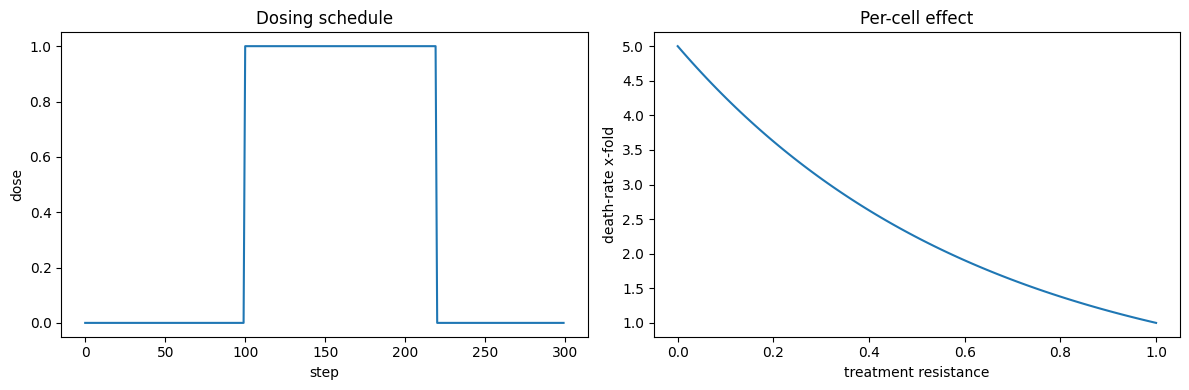

In [5]:
chemo = iscc.treatment.Chemotherapy(adaptive=False, start=100, duration=120,
                                    effectiveness=1.0, toxicity=0.1, rate_multiplier=5.0)
steps = np.arange(0, 300)
dose = [chemo.get_dosage(s, tumor_size=1000) for s in steps]

resistance = np.linspace(0, 1, 100)
mult = chemo.rate_multiplier ** (1 - resistance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(steps, dose); axes[0].set_xlabel("step"); axes[0].set_ylabel("dose")
axes[0].set_title("Dosing schedule")
axes[1].plot(resistance, mult); axes[1].set_xlabel("treatment resistance")
axes[1].set_ylabel("death-rate x-fold"); axes[1].set_title("Per-cell effect")
plt.tight_layout()

> The population-level *magnitude* of response is currently muted by the default
> treatment-resistance parameterization (cells start highly resistant); making longitudinal
> pre/post-treatment response realistic is part of the treatment-realism milestone. The
> scheduling and per-cell mechanics shown here are what that work will build on.

**Next:** [Exploring the data](03_data_overview.ipynb) takes a sample of a tumor like this one and walks through
every molecular assay (bulk/single-cell DNA, scRNA, Visium).